<a href="https://colab.research.google.com/github/niksisons/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B0%D0%B2%D1%82%D0%BE%D1%8D%D0%BD%D0%BA%D0%BE%D0%B4%D0%B5%D1%80%D0%BE%D0%B2_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%BF%D1%80%D0%B8%D0%BA%D0%BB%D0%B0%D0%B4%D0%BD%D1%8B%D1%85_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №6. Проектирование автоэнкодеров для решения прикладных задач**


## **Задание №1. Реализуйте автоэнкодер для колоризации чёрно-белых изображений**



* **Чем больше объектов разных классов будет в исходном датасете, тем универсальнее будет работа обученной Вами модели**

> Например, если в Вашем датасете только кошки, то все объекты кроме кошек будут колоризоваться некорректно. Соответственно следует очень тщательно подойти к выбору датасета.

  * Для решения данной задачи может подойти датасет [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100), но его минус заключается в том, что разрешение изображений довольно низкое

* Хорошим вариантом будет использование датасета [ImageNet](https://paperswithcode.com/dataset/imagenet), но ввиду его объёмности, процесс обучения займет большое количество времени, поэтому Вы можете использовать одну из его [сокращенных версий](https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000)



 **Конечный выбор датасета осуществляется по Вашему желанию (хорошо, если это будут Ваши датасеты), учитывая рекомендации приведенные выше.**


Using Colab cache for faster access to the 'images-dataset' dataset.
Путь к датасету: /kaggle/input/images-dataset
Итоговый путь к папкам классов: /kaggle/input/images-dataset/data/data
Список найденных папок (классов): ['horses', 'cars', 'dogs', 'flowers', 'bike', 'cats', 'human']
Found 1803 files belonging to 7 classes.
Определенные классы: ['bike', 'cars', 'cats', 'dogs', 'flowers', 'horses', 'human']
Вход (Ч/Б) shape: (32, 224, 224, 1)
Выход (Цветное) shape: (32, 224, 224, 3)


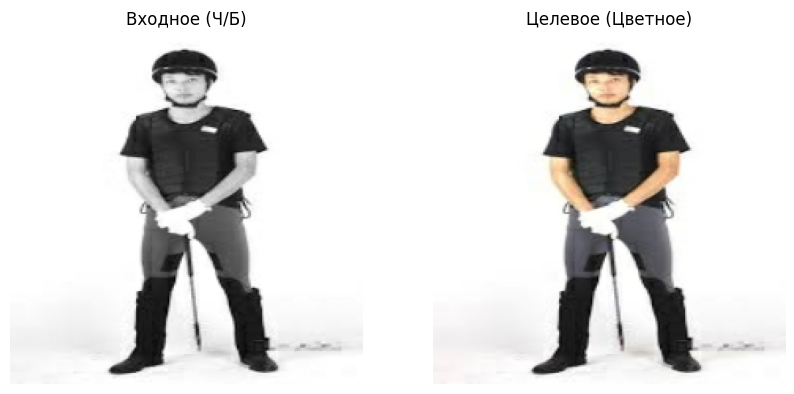

In [6]:
import os
import kagglehub
from pathlib import Path
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


path = kagglehub.dataset_download("pavansanagapati/images-dataset")
print("Путь к датасету:", path)

data_path = os.path.join(path, 'data', 'data')
if not os.path.exists(data_path):
    data_path = os.path.join(path, 'data')
if not os.path.exists(data_path):
    data_path = path

print("Итоговый путь к папкам классов:", data_path)
print("Список найденных папок (классов):", os.listdir(data_path))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Формирование датасета
dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True
)

class_names = dataset.class_names
print("Определенные классы:", class_names)


normalized_ds = dataset.map(lambda x, y: x / 255.0)

def prepare_colorization_data(img):
    gray_img = tf.image.rgb_to_grayscale(img)
    return gray_img, img

colorization_dataset = normalized_ds.map(prepare_colorization_data)

# Визуализация
for x_batch, y_batch in colorization_dataset.take(1):
    print("Вход (Ч/Б) shape:", x_batch.shape)
    print("Выход (Цветное) shape:", y_batch.shape)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Входное (Ч/Б)')
    plt.imshow(tf.squeeze(x_batch[0]), cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Целевое (Цветное)')
    plt.imshow(y_batch[0])
    plt.axis('off')
    plt.show()

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Задание 1: Колоризация (архитектура, адаптированная под 224x224)
def build_colorization_autoencoder():
    # Энкодер (вход - ч/б изображение 224x224x1)
    encoder_input = layers.Input(shape=(224, 224, 1))

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # 112x112
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # 56x56
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # 28x28

    # Декодер (выход - цветное изображение 224x224x3)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x) # 56x56
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x) # 112x112
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x) # 224x224
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

colorization_model = build_colorization_autoencoder()
# colorization_model.summary()

train_ds = colorization_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

print("Начинается полноценное обучение на всем датасете...")

history = colorization_model.fit(train_ds, epochs=20)
print("Обучение завершено.")

Начинается полноценное обучение на всем датасете...
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 64s 464ms/step - loss: 0.0327
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step - loss: 0.0137
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 239ms/step - loss: 0.0121
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - loss: 0.0112
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - loss: 0.0109
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - loss: 0.0105
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 247ms/step - loss: 0.0103
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step - loss: 0.0100
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - loss: 0.0099
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 249ms/step - loss: 0.0096
Epoch 11/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 249ms/step - loss: 0.0094
Epoch 12/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step - loss: 0.0092
Epoch 13/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - loss: 0.0093
Epoch 14/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - loss

## **Задание №2. Реализуйте автоэнкодер для удаления шума на однотипных изображениях**



1.  Подберите датасет, состоящий из однотипных изображений, которые в реальной жизни часто подвержены зашумлению, например спутниковые снимки, ночные фотографии и т.д.

2.  Затем примените к ним операцию зашумления и обучите модель. Также учитывайте тип шума, который Вы применяете. Он должен быть приближен к естественному.

Хороший пример реализации подобной задачи: https://www.kaggle.com/code/michalbrezk/denoise-images-using-autoencoders-tf-keras

In [3]:
def build_denoising_autoencoder():
    # Энкодер (вход 64x64x3)
    encoder_input = layers.Input(shape=(64, 64, 3))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Декодер
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

denoising_model = build_denoising_autoencoder()
denoising_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

## **Задание №.3 Реализуйте автоэнкодер для улучшения качества изображения путём увеличения его разрешения (апскейлинг-[определение](https://dic.academic.ru/dic.nsf/ruwiki/346555))**



1. На входной слой нейронной сети подаётся изображение с размерностью (256, 256,3) - X_test. В результате работы нейронной сети на выходном слое должно получиться изображение (512, 512, 3) - Y_test. В итоге мы получаем двукратный апскейл исходного изображения.

2. Датасет собираете из изображений, разрешение которых выше эталонного (512,512,3). Затем преобразуете их в указанные размерности и формируете из них обучающую и проверочную выборку.

3. Обучите модель. Отобразите графики обучения

4. Подумайте, каким образом можно будет адаптировать модель вашей нейронной сети для двухратного апскейла изображения с любой размерностью, большей, чем (256,256,3), с полным или частичным сохранением его исходных пропорций. Например: подаём на вход изображение с разрешением (1920, 1080, 3) - получаем изображение с разрешением (3840, 2160, 3), т.е. с полным сохранением исходных пропорций или (1792, 1024, 3) с частичным сохранением исходных пропорций.

> Подсказка: Для этого можно реализовать алгоритм предварительной обработки исходного изображения, перед подачей его в нейронную сеть

In [4]:
def build_upscaling_autoencoder():
    # Вход: 256x256x3
    encoder_input = layers.Input(shape=(256, 256, 3))

    # Извлечение признаков (без сильного сжатия размерности, чтобы не терять детали)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Апскейлинг в 2 раза
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

upscaling_model = build_upscaling_autoencoder()
upscaling_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 512, 512, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 512, 512, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 512, 512, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 512, 512, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,771 (659.26 KB)

 Trainable params: 168,771 (659.26 KB)

 Non-trainable params: 0 (0.00 B)

## **Демонстрация работы: Колоризация пользовательских изображений**

Загрузите изображения:


Saving chau-chau.jpg to chau-chau.jpg
Saving images (3).jpg to images (3) (2).jpg
Saving images (2).jpg to images (2) (2).jpg
Обработка chau-chau.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


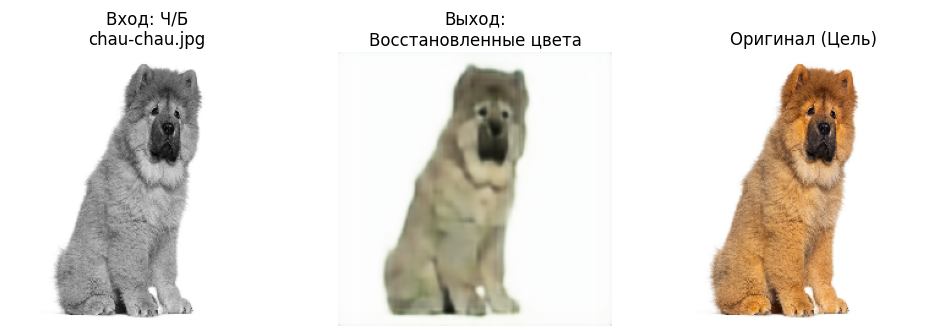

Обработка images (3) (2).jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


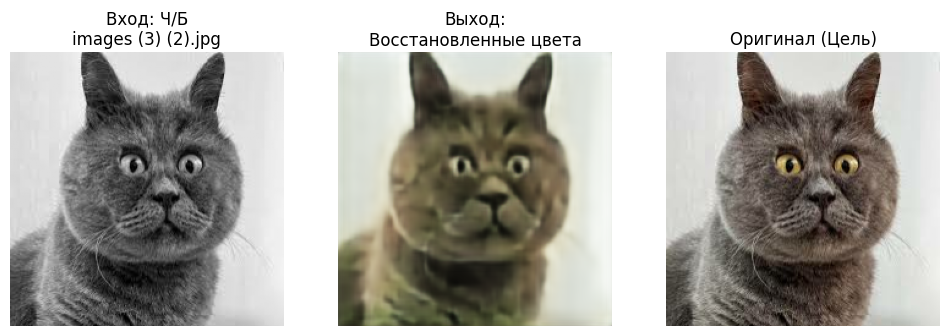

Обработка images (2) (2).jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


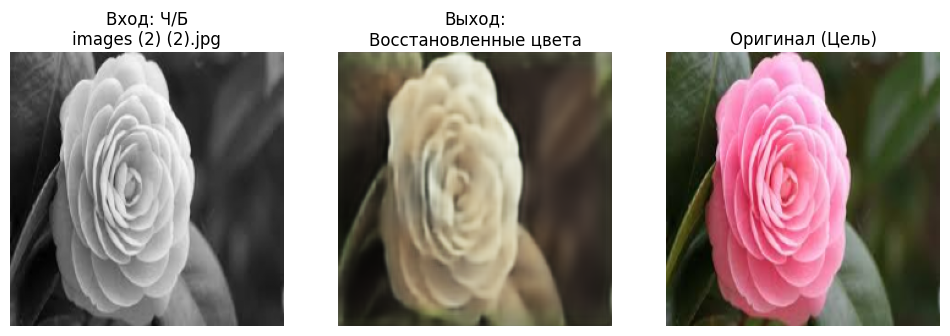

In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def process_and_display_image(img_array, title_suffix=""):
    if isinstance(img_array, str):
        img_raw = tf.io.read_file(img_array)
        img = tf.image.decode_image(img_raw, channels=3)
        img = tf.image.resize(img, (224, 224))
        img = img / 255.0
    else:
        img = img_array

    gray_img = tf.image.rgb_to_grayscale(img)
    inp = tf.expand_dims(gray_img, 0)
    colorized_img = colorization_model.predict(inp)[0]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title(f'Вход: Ч/Б\n{title_suffix}')
    plt.imshow(tf.squeeze(gray_img), cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title(f'Выход:\nВосстановленные цвета')
    plt.imshow(colorized_img)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f'Оригинал (Цель)')
    plt.imshow(img)
    plt.axis('off')

    plt.show()

if IN_COLAB:
    print("Загрузите изображения:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"Обработка {filename}...")
        process_and_display_image(filename, title_suffix=filename)
else:
    print("работает только в среде Google Colab.")
    print("Проводим демонстрацию на случайном изображении из датасета:")
    for x_batch, y_batch in colorization_dataset.take(1):
        process_and_display_image(y_batch[0], title_suffix="(из датасета)")
        break